In [ ]:
/Users/tatiana/Documents_new/pang/visor_freqk/summaries/results.ipynb

# rm -rf beds/* haplotypes/* reads/* vcf/*

In [ ]:
# there might be a problem with this 

tbellagio@login1:~/scratch/pang/visor_freqk$ python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.10

In [ ]:
python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.10 --positions 20000000 30000000 10000000 
python scripts/launch_experiment.py --sv-type INS --coverage 50 --freq 0.10 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.30 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 50 --freq 0.30 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.50 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 50 --freq 0.50 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 20 --freq 0.10 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 20 --freq 0.10 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 20 --freq 0.30 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 20 --freq 0.30 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 20 --freq 0.50 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 20 --freq 0.50 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 10 --freq 0.10 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 10 --freq 0.10 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 10 --freq 0.30 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 10 --freq 0.30 --positions 20000000 30000000 10000000

python scripts/launch_experiment.py --sv-type DEL --coverage 10 --freq 0.50 --positions 20000000 30000000 10000000
python scripts/launch_experiment.py --sv-type INS --coverage 10 --freq 0.50 --positions 20000000 30000000 10000000



In [ ]:
bash scripts/check_timing.sh logs/pipeline_var_20260316_XXXXXX.jobids

bash scripts/check_timing.sh logs/pipeline_var_20260316_140111.jobids

In [ ]:
python scripts/launch_experiment_var.py \
    --sv-type DEL \
    --coverage 10 20 50 \
    --sv-freq 0.10 0.30 0.50 0.7 0.9 \
    --n-samples 231 \
    --sizes 100bp 500bp 1kb 5kb 10kb \
    --positions 15000000 \
    --stagger-secs 30


In [ ]:
python scripts/launch_experiment_var.py \
    --sv-type DEL \
    --coverage 10 20 50 \
    --sv-freq 0.10 0.30 0.50 0.7 0.9 \
    --n-samples 231 \
    --sizes 100bp 500bp 1kb 5kb 10kb \
    --positions 20000000 \
    --stagger-secs 30

In [ ]:
python scripts/launch_experiment_var.py \
    --sv-type DEL \
    --coverage 10 20 50 \
    --sv-freq 0.10 0.30 0.50 0.7 0.9 \
    --n-samples 231 \
    --sizes 100bp 500bp 1kb 5kb 10kb \
    --positions 20000000 \
    --stagger-secs 30

In [ ]:
python scripts/launch_experiment_var.py \
    --sv-type DEL \
    --coverage 10 20 50 \
    --sv-freq 0.10 0.30 0.50 0.7 0.9 \
    --n-samples 231 \
    --sizes 100bp 500bp 1kb 5kb 10kb \
    --positions 14960000  \
    --stagger-secs 30


python scripts/launch_experiment_var.py \
    --sv-type DEL \
    --coverage 10 20 50 \
    --sv-freq 0.9 \
    --n-samples 231 \
    --sizes 100bp 500bp 1kb 5kb 10kb \
    --positions 15000000 \
    --stagger-secs 30


In [ ]:
3*5*5  first submit hte highest frequency! 

75

In [ ]:
python scripts/launch_experiment_var.py \
    --sv-type DEL \
    --coverage 10 20 50 \
    --sv-freq 0.10 0.30 0.50 0.7 0.9 \
    --n-samples 231 \
    --sizes 100bp 500bp 1kb 5kb 10kb \
    --positions 14725000  \
    --stagger-secs 30

In [6]:
import re
import os
import glob
from pathlib import Path
import pandas as pd

results_dir = Path('/Users/tatiana/Documents_new/visor_freqk/results')

# New path structure:
#   results/{sv_root}/{pos_label}/{cov_err}/{SV_TYPE}/{size}/{freq}/{k}/filename
# pos_label matches pos\d+mb (e.g. pos10mb, pos20mb) — this is what separates
# new-format results from old ones (which had cov_err at parts[1]).

NEW_FORMAT = re.compile(r'^pos\d+mb$')

all_files   = sorted(results_dir.rglob('*.allele_frequencies.k*.tsv'))
new_files   = [f for f in all_files
               if len(f.relative_to(results_dir).parts) == 8
               and NEW_FORMAT.match(f.relative_to(results_dir).parts[1])]
old_skipped = len(all_files) - len(new_files)

print(f"Total .tsv files found : {len(all_files)}")
print(f"Old-format (skipped)   : {old_skipped}")
print(f"New-format (loaded)    : {len(new_files)}\n")

print(f"{'sv':3s}  {'pos':8s}  {'cov/err':12s}  {'SV':3s}  {'size':5s}  {'freq':4s}  {'k':4s}")
print("-" * 65)
for f in new_files:
    p = f.relative_to(results_dir).parts
    print(f"{p[0]:3s}  {p[1]:8s}  {p[2]:12s}  {p[3]:3s}  {p[4]:5s}  {p[5]:4s}  {p[6]:4s}")


Total .tsv files found : 450
Old-format (skipped)   : 0
New-format (loaded)    : 450

sv   pos       cov/err       SV   size   freq  k   
-----------------------------------------------------------------
del  pos10mb   cov10_err001  DEL  100bp  f10   k31 
del  pos10mb   cov10_err001  DEL  100bp  f30   k31 
del  pos10mb   cov10_err001  DEL  100bp  f50   k31 
del  pos10mb   cov10_err001  DEL  100bp  f70   k31 
del  pos10mb   cov10_err001  DEL  100bp  f90   k31 
del  pos10mb   cov10_err001  DEL  10kb   f10   k31 
del  pos10mb   cov10_err001  DEL  10kb   f30   k31 
del  pos10mb   cov10_err001  DEL  10kb   f50   k31 
del  pos10mb   cov10_err001  DEL  10kb   f70   k31 
del  pos10mb   cov10_err001  DEL  10kb   f90   k31 
del  pos10mb   cov10_err001  DEL  1kb    f10   k31 
del  pos10mb   cov10_err001  DEL  1kb    f30   k31 
del  pos10mb   cov10_err001  DEL  1kb    f50   k31 
del  pos10mb   cov10_err001  DEL  1kb    f70   k31 
del  pos10mb   cov10_err001  DEL  1kb    f90   k31 
del  pos10mb   c

In [7]:
rows = []

for f in new_files:
    p = f.relative_to(results_dir).parts
    # p: (sv_root, pos_label, cov_err, SV_TYPE, size, freq_label, k_label, filename)
    sv_root   = p[0]   # 'del' | 'ins'
    pos_label = p[1]   # 'pos10mb'
    cov_err   = p[2]   # 'cov50_err0' | 'cov50_err001'
    sv_type   = p[3]   # 'DEL' | 'INS'
    size      = p[4]   # '100bp' | '1kb' | ...
    freq_lbl  = p[5]   # 'f50'
    k_lbl     = p[6]   # 'k31'

    # Parse coverage from cov_err
    cov_part, err_part = cov_err.split('_')
    coverage = int(cov_part.replace('cov', ''))

    # Parse error_rate: label is decimal digits after the dot
    # err0 → 0.0,  err01 → 0.01,  err001 → 0.001
    err_str = err_part.replace('err', '')
    error_rate = 0.0 if err_str == '0' else float('0.' + err_str)

    # Parse nominal frequency: f50 → 0.50, f10 → 0.10
    freq_nominal = int(freq_lbl.replace('f', '')) / 100.0

    # Parse k
    k = int(k_lbl.replace('k', ''))

    # Read AF values (single line: 'af_ref|af_alt')
    line = f.read_text().strip()
    af_parts = line.split('|')
    af_ref = float(af_parts[0])
    af_alt = float(af_parts[1]) if len(af_parts) > 1 else float('nan')

    rows.append({
        'sv_root'     : sv_root,
        'sv_type'     : sv_type,
        'pos_label'   : pos_label,   # replicate identity
        'cov_err'     : cov_err,
        'coverage'    : coverage,
        'error_rate'  : error_rate,
        'size'        : size,
        'freq_label'  : freq_lbl,
        'freq_nominal': freq_nominal,
        'k_label'     : k_lbl,
        'k'           : k,
        'file'        : str(f),
        'af_ref'      : af_ref,
        'af_alt'      : af_alt,
    })

results_df = pd.DataFrame(rows)

# Derived metrics
results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]
results_df["abs_error"] = results_df["error"].abs()
results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

print(f"Loaded {len(results_df)} rows  |  "
      f"positions: {sorted(results_df['pos_label'].unique())}  |  "
      f"coverages: {sorted(results_df['coverage'].unique())}  |  "
      f"error_rates: {sorted(results_df['error_rate'].unique())}")
results_df.sort_values(['sv_type', 'coverage', 'pos_label']).head(10)


Loaded 450 rows  |  positions: ['pos10mb', 'pos20mb', 'pos30mb']  |  coverages: [10, 20, 50]  |  error_rates: [0.001]


,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt,error,abs_error,rel_error
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.896892,0.103108,0.003108,0.003108,0.031082
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.753996,0.246004,-0.053996,0.053996,0.179986
2,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.598318,0.401682,-0.098318,0.098318,0.196636
3,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.222567,0.777433,0.077433,0.077433,0.110619
4,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f90,0.9,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.392157,0.607843,-0.292157,0.292157,0.324619
5,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,1.000000,0.000000,-0.100000,0.100000,1.000000
6,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.812661,0.187339,-0.112661,0.112661,0.375536
7,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.417924,0.582076,0.082076,0.082076,0.164153
8,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.678474,0.321526,-0.378474,0.378474,0.540677
9,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,f90,0.9,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.254386,0.745614,-0.154386,0.154386,0.171540


In [8]:
results_df.sort_values(['sv_type','coverage'])

,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt,error,abs_error,rel_error
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.896892,0.103108,0.003108,0.003108,0.031082
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.753996,0.246004,-0.053996,0.053996,0.179986
2,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.598318,0.401682,-0.098318,0.098318,0.196636
3,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.222567,0.777433,0.077433,0.077433,0.110619
4,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f90,0.9,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.392157,0.607843,-0.292157,0.292157,0.324619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.916493,0.083506,-0.016494,0.016494,0.164935
446,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.649575,0.350425,0.050425,0.050425,0.168083
447,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.471573,0.528428,0.028428,0.028428,0.056855
448,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.225225,0.774775,0.074775,0.074775,0.106822


In [9]:
import seaborn as sns

In [10]:
# ── Compute error metrics ──────────────────────────────────────────────────────
results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]   # signed bias
results_df["abs_error"] = results_df["error"].abs()
results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

results_df[["sv_type","coverage","error_rate","size","freq_nominal","af_alt","error","abs_error"]].head(10)


,sv_type,coverage,error_rate,size,freq_nominal,af_alt,error,abs_error
0,DEL,10,0.001,100bp,0.1,0.103108,0.003108,0.003108
1,DEL,10,0.001,100bp,0.3,0.246004,-0.053996,0.053996
2,DEL,10,0.001,100bp,0.5,0.401682,-0.098318,0.098318
3,DEL,10,0.001,100bp,0.7,0.777433,0.077433,0.077433
4,DEL,10,0.001,100bp,0.9,0.607843,-0.292157,0.292157
5,DEL,10,0.001,10kb,0.1,0.000000,-0.100000,0.100000
6,DEL,10,0.001,10kb,0.3,0.187339,-0.112661,0.112661
7,DEL,10,0.001,10kb,0.5,0.582076,0.082076,0.082076
8,DEL,10,0.001,10kb,0.7,0.321526,-0.378474,0.378474
9,DEL,10,0.001,10kb,0.9,0.745614,-0.154386,0.154386


In [11]:
results_df = results_df[results_df['error_rate'] == 0.001]	

In [19]:
results_df.to_csv('/Users/tatiana/Documents_new/visor_freqk/summaries/results_mar11_poslabel.csv',index=False)

In [13]:
results_df

,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt,error,abs_error,rel_error
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.896892,0.103108,0.003108,0.003108,0.031082
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.753996,0.246004,-0.053996,0.053996,0.179986
2,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.598318,0.401682,-0.098318,0.098318,0.196636
3,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.222567,0.777433,0.077433,0.077433,0.110619
4,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f90,0.9,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.392157,0.607843,-0.292157,0.292157,0.324619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.916493,0.083506,-0.016494,0.016494,0.164935
446,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.649575,0.350425,0.050425,0.050425,0.168083
447,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.471573,0.528428,0.028428,0.028428,0.056855
448,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.225225,0.774775,0.074775,0.074775,0.106822


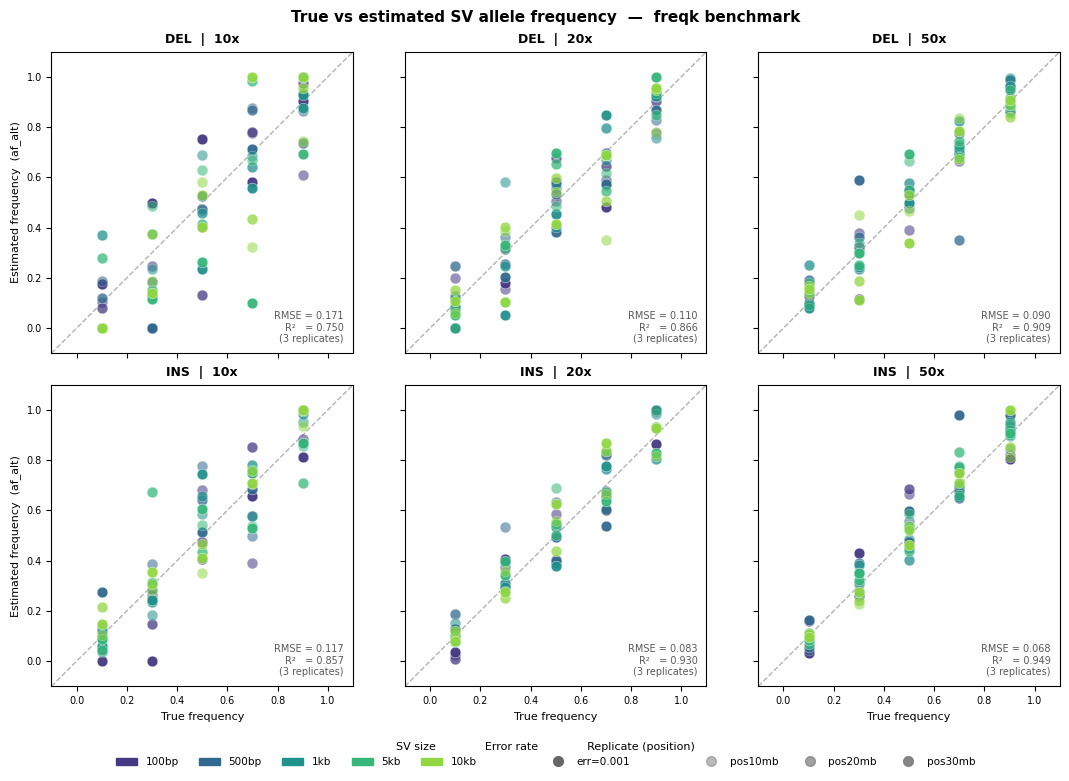

In [21]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from pathlib import Path

# ── Aesthetics ─────────────────────────────────────────────────────────────────
SIZE_ORDER  = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette     = sns.color_palette("viridis", len(SIZE_ORDER))
SIZE_COLORS = dict(zip(SIZE_ORDER, palette))

# Each error_rate gets a marker shape; positions (replicates) are individual dots
error_rates  = sorted(results_df["error_rate"].unique())
ERR_MARKERS  = dict(zip(error_rates, ["o", "s", "^", "D"]))

# Each replicate position gets an alpha level to make overlap visible
positions    = sorted(results_df["pos_label"].unique())
POS_ALPHA    = {p: a for p, a in zip(positions, np.linspace(0.55, 0.95, len(positions)))}

sv_types  = ["DEL", "INS"]
coverages = sorted(results_df["coverage"].unique())

# ── Layout: rows = sv_type, cols = coverage ────────────────────────────────────
nrows, ncols = len(sv_types), len(coverages)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6 * ncols, 3.6 * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
if nrows == 1: axes = [axes]
if ncols == 1: axes = [[ax] for ax in axes]

lo, hi = -0.1, 1.1

for i, svt in enumerate(sv_types):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        subset = results_df[(results_df["sv_type"] == svt) & (results_df["coverage"] == cov)]

        # Plot every replicate position as a separate dot
        for err in error_rates:
            for size in SIZE_ORDER:
                for pos in positions:
                    pts = subset[
                        (subset["error_rate"] == err) &
                        (subset["size"]       == size) &
                        (subset["pos_label"]  == pos)
                    ]
                    if pts.empty:
                        continue
                    ax.scatter(
                        pts["freq_nominal"], pts["af_alt"],
                        color      = SIZE_COLORS.get(size, "grey"),
                        marker     = ERR_MARKERS.get(err, "x"),
                        alpha      = POS_ALPHA[pos],
                        s          = 60,
                        edgecolors = "white",
                        linewidths = 0.3,
                        zorder     = 3,
                    )

        # Identity line
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--", alpha=0.3, zorder=1)

        # RMSE and R² over all replicates
        if not subset.empty:
            rmse  = np.sqrt(((subset["af_alt"] - subset["freq_nominal"]) ** 2).mean())
            r2    = np.corrcoef(subset["freq_nominal"], subset["af_alt"])[0, 1] ** 2
            n_rep = subset["pos_label"].nunique()
            ax.text(0.97, 0.03,
                    f"RMSE = {rmse:.3f}\nR²   = {r2:.3f}\n({n_rep} replicates)",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_title(f"{svt}  |  {cov}x", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Estimated frequency  (af_alt)", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── Legends ────────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
err_handles  = [
    mlines.Line2D([], [], color="0.4", marker=ERR_MARKERS[e], linestyle="None",
                  markersize=7, label=f"err={e}")
    for e in error_rates
]
pos_handles  = [
    mlines.Line2D([], [], color="0.5", marker="o", linestyle="None",
                  markersize=7, alpha=POS_ALPHA[p], label=p)
    for p in positions
]

fig.legend(
    handles=size_patches
            + [mpatches.Patch(visible=False)]
            + err_handles
            + [mpatches.Patch(visible=False)]
            + pos_handles,
    title="SV size              Error rate              Replicate (position)",
    loc="lower center",
    ncol=len(SIZE_ORDER) + 1 + len(err_handles) + 1 + len(pos_handles),
    fontsize=7.5, title_fontsize=8,
    bbox_to_anchor=(0.5, -0.07),
    frameon=False,
)

fig.suptitle("True vs estimated SV allele frequency  —  freqk benchmark",
             fontsize=11, fontweight="bold")

Path("/Users/tatiana/Documents_new/visor_freqk/plots/").mkdir(exist_ok=True)
fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated.pdf", bbox_inches="tight")
fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated.png", bbox_inches="tight", dpi=150)
plt.show()


In [22]:
results_df

,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt,error,abs_error,rel_error
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.896892,0.103108,0.003108,0.003108,0.031082
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.753996,0.246004,-0.053996,0.053996,0.179986
2,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.598318,0.401682,-0.098318,0.098318,0.196636
3,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.222567,0.777433,0.077433,0.077433,0.110619
4,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f90,0.9,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.392157,0.607843,-0.292157,0.292157,0.324619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.916493,0.083506,-0.016494,0.016494,0.164935
446,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.649575,0.350425,0.050425,0.050425,0.168083
447,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.471573,0.528428,0.028428,0.028428,0.056855
448,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.225225,0.774775,0.074775,0.074775,0.106822
